In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive (3).zip to archive (3) (2).zip


In [5]:
import os
print(os.listdir())

['.config', 'archive (3).zip', 'archive (3) (1).zip', 'archive (3) (2).zip', 'sample_data']


In [6]:
import zipfile
import os

# Replace with your ZIP file name
zip_file = 'archive (3) (2).zip'

# Extract the ZIP file
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall()

print("Files after extraction:")
print(os.listdir())

Files after extraction:
['.config', 'archive (3).zip', 'Unemployment_Rate_upto_11_2020.csv', 'archive (3) (1).zip', 'archive (3) (2).zip', 'sample_data']


In [7]:
import pandas as pd

df = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [9]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [13]:
# Check for missing values
print(df.isnull().sum())

# Check for duplicate records
print("Duplicate rows:", df.duplicated().sum())

# Convert Date column to datetime format
df[' Date'] = pd.to_datetime(df[' Date'], dayfirst=True)

# Display cleaned dataset information
df.info()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64
Duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   Region                                    267 non-null    object        
 1    Date                                     267 non-null    datetime64[ns]
 2    Frequency                                267 non-null    object        
 3    Estimated Unemployment Rate (%)          267 non-null  

In [14]:
print(df.describe())

print("\nNumber of regions:")
print(df['Region'].nunique())

print("\nRegions in dataset:")
print(df['Region'].unique())

                                Date   Estimated Unemployment Rate (%)  \
count                            267                        267.000000   
mean   2020-06-16 09:15:30.337078528                         12.236929   
min              2020-01-31 00:00:00                          0.500000   
25%              2020-03-31 00:00:00                          4.845000   
50%              2020-06-30 00:00:00                          9.650000   
75%              2020-08-31 00:00:00                         16.755000   
max              2020-10-31 00:00:00                         75.850000   
std                              NaN                         10.803283   

        Estimated Employed   Estimated Labour Participation Rate (%)  \
count         2.670000e+02                                267.000000   
mean          1.396211e+07                                 41.681573   
min           1.175420e+05                                 16.770000   
25%           2.838930e+06                   

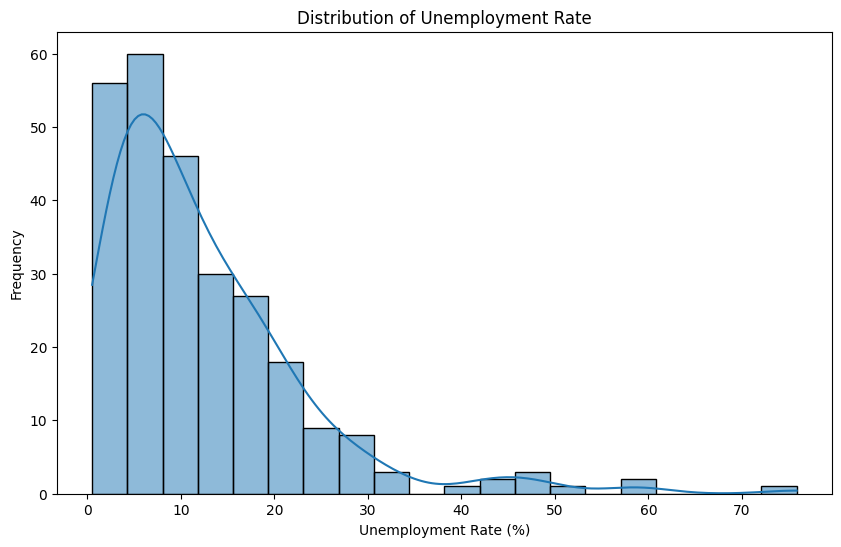

In [23]:
plt.figure(figsize=(10,6))
sns.histplot(df[' Estimated Unemployment Rate (%)'], bins=20, kde=True)
plt.title('Distribution of Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.show()

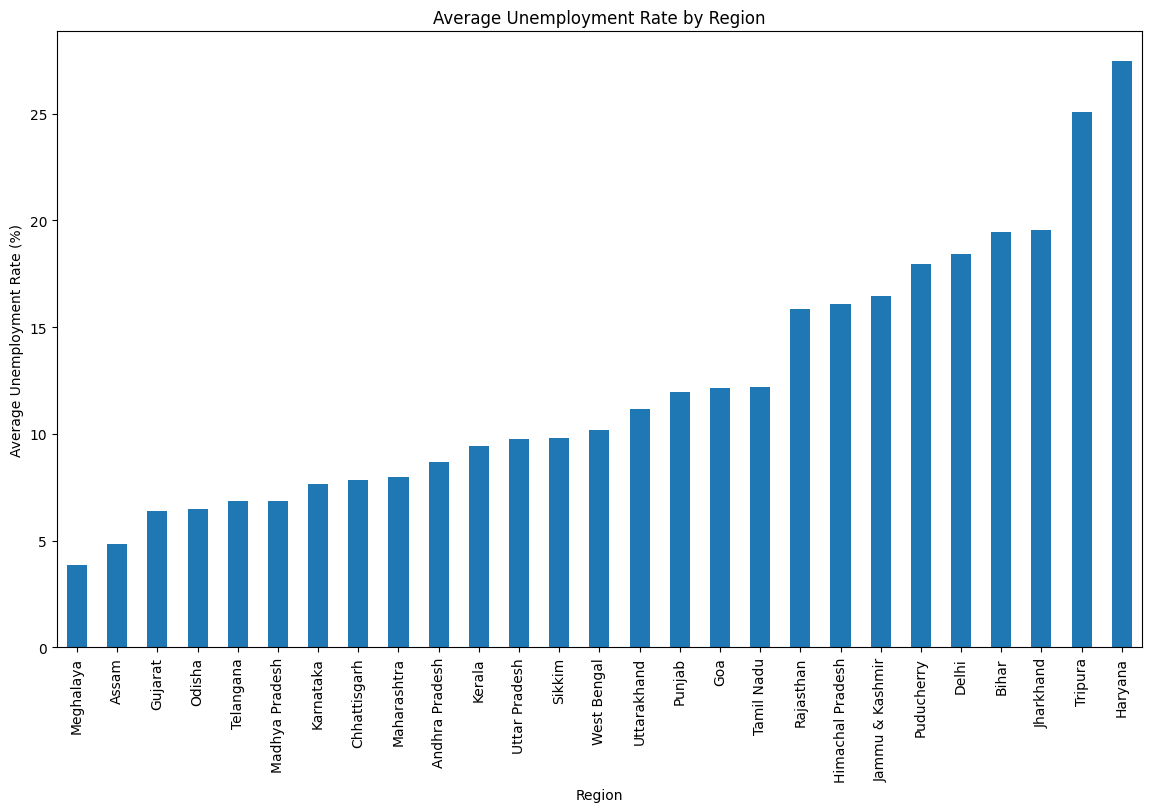

In [21]:
plt.figure(figsize=(14,8))

avg_unemployment = df.groupby('Region')[' Estimated Unemployment Rate (%)'].mean().sort_values()

avg_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.show()

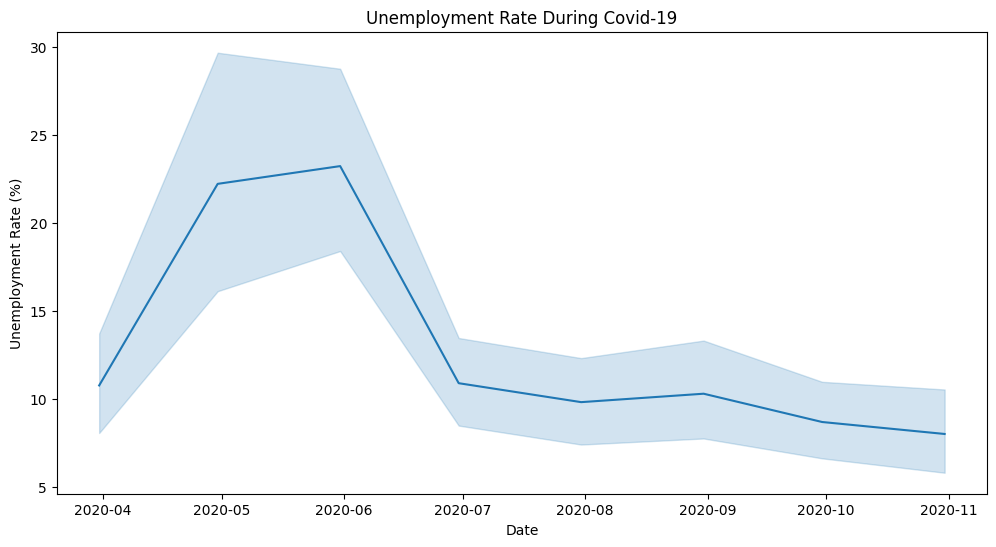

In [19]:
covid_data = df[df[' Date'] >= '2020-03-01']

plt.figure(figsize=(12,6))

sns.lineplot(
    data=covid_data,
    x=' Date',
    y=' Estimated Unemployment Rate (%)'
)

plt.title('Unemployment Rate During Covid-19')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.show()

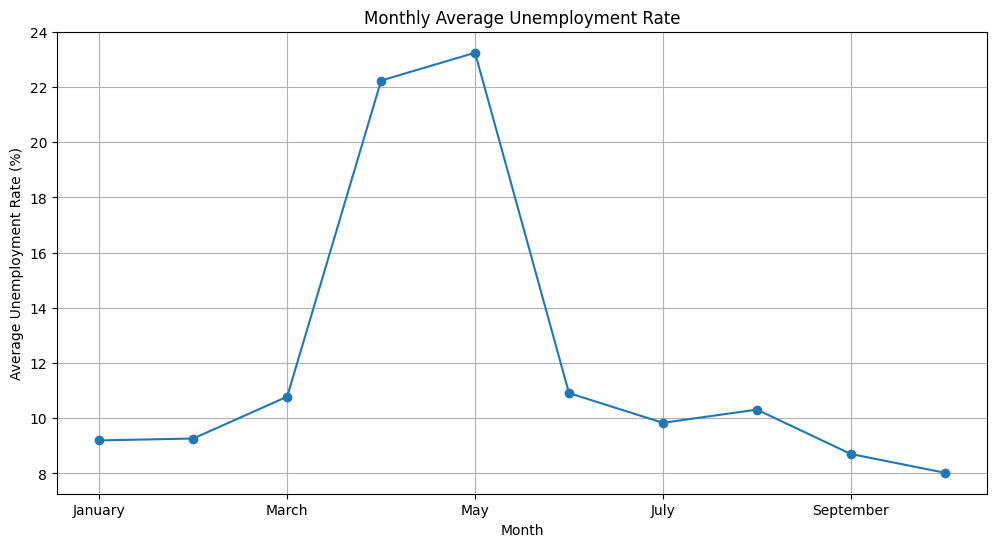

In [17]:
df['Month'] = df[' Date'].dt.month_name()

monthly_avg = df.groupby('Month')[' Estimated Unemployment Rate (%)'].mean()

monthly_avg = monthly_avg.reindex(
    ['January','February','March','April','May',
    'June','July','August','September',
    'October','November','December']
)

plt.figure(figsize=(12,6))

monthly_avg.plot(marker='o')

plt.title('Monthly Average Unemployment Rate')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.grid(True)

plt.show()

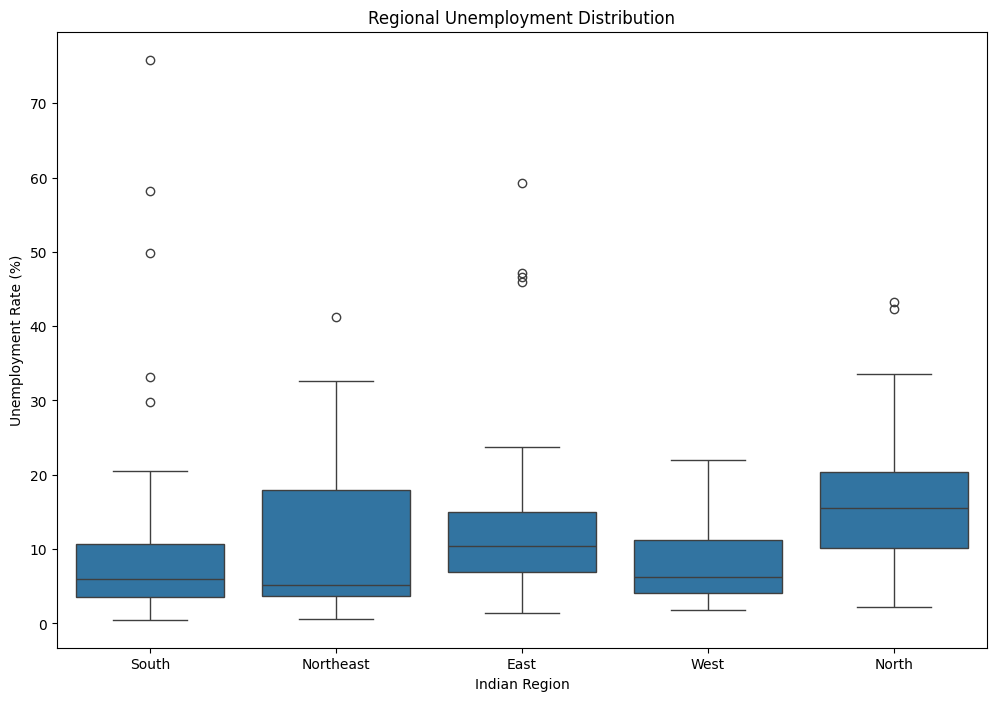

In [18]:
plt.figure(figsize=(12,8))

sns.boxplot(
    x='Region.1',
    y=' Estimated Unemployment Rate (%)',
    data=df
)

plt.title('Regional Unemployment Distribution')
plt.xlabel('Indian Region')
plt.ylabel('Unemployment Rate (%)')

plt.show()

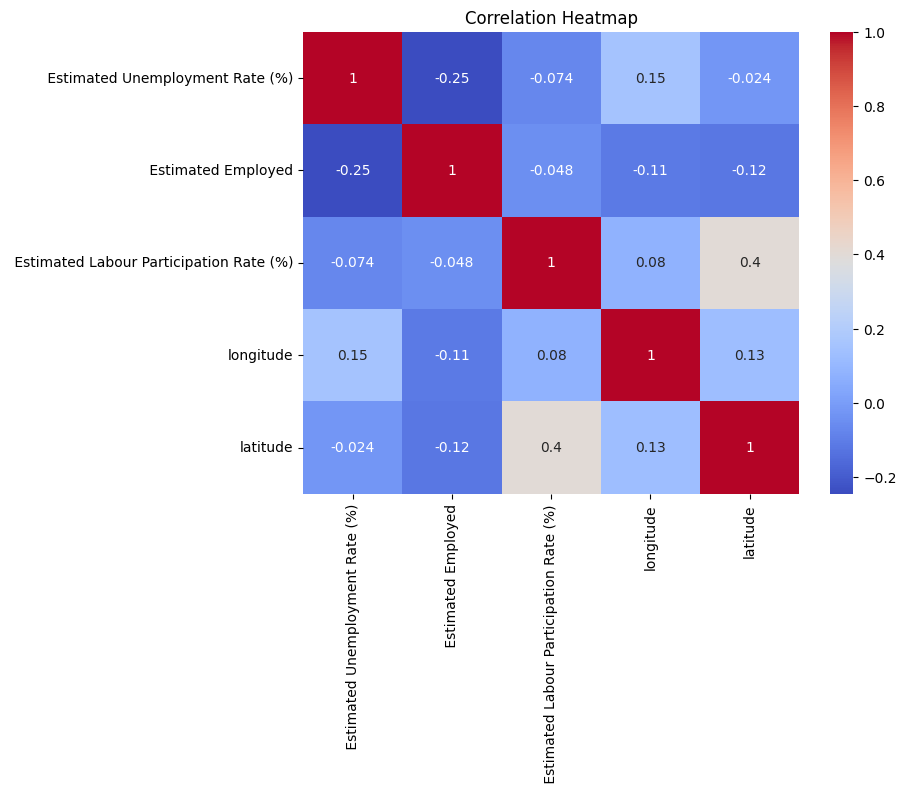

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()